# Stage 6: Information Value (IV)
## Meridian Trust Bank — Personal Loan Application Credit Scorecard

**Business question:** of all the candidate variables we binned in Stage 5,
which ones actually carry enough predictive signal to be worth including in
the model?

## What IV measures

Information Value sums each bin's contribution across the whole variable:

$$IV = \sum_{i} (\% Good_i - \% Bad_i) \times WOE_i$$

It's a single number per variable that answers: "how well does this variable
SEPARATE Good from Bad overall?" A variable where every bin has an identical
Good:Bad ratio (no separation at all) has IV = 0. A variable that perfectly
separates Good from Bad has IV approaching infinity (in practice, capped by
how extreme your WOE values get).

## The conventional IV interpretation bands (used industry-wide, though the
exact thresholds are convention, not a law of statistics):

| IV range | Interpretation |
|---|---|
| < 0.02 | Not useful for prediction |
| 0.02 – 0.10 | Weak predictive power |
| 0.10 – 0.30 | Medium predictive power |
| 0.30 – 0.50 | Strong predictive power |
| > 0.50 | Suspiciously strong — investigate for leakage/overfitting |

**That last row matters a lot and is often skipped by beginners.** An IV
above ~0.5 is NOT automatically good news — it's a signal to go check whether
the variable is actually a proxy for the target itself (data leakage), or
whether it's an artifact of how bins were constructed on the very data being
measured (overfitting the bin boundaries to this specific sample). We'll
watch for this explicitly below.

## IV's real limitations (why it's ONE input, not the only one)

1. **IV is univariate.** It measures a variable's relationship with the
   target in isolation, ignoring correlation with other variables. Two
   variables can each have decent IV individually while being redundant with
   each other (e.g. `total_existing_debt` and `credit_utilization_pct`,
   flagged as correlated back in Stage 4.9) — IV alone won't tell you that.
2. **IV is computed using the SAME bins that were fit on this data** (Stage
   5's coarse classing was supervised — it used the target to choose bin
   boundaries). This makes IV here somewhat optimistic/in-sample. The honest
   fix is to validate IV stability on a held-out sample, which we'll do in
   Stage 9 — for now, treat this stage's IV values as a first-pass filter,
   not a final verdict.
3. **IV doesn't know about business logic.** A variable can have decent IV
   purely by chance, especially with modest sample sizes and many candidate
   bins — statistical significance and business sense both still matter.
4. **IV doesn't account for regulatory/fair-lending constraints.** A
   variable might have strong IV but be legally or ethically inappropriate
   to use (this project doesn't include any protected-attribute-adjacent
   variables like `gender` as a *modeling* candidate for exactly this
   reason — see the variable selection discussion below).

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

df = pd.read_csv('../01_data/raw_csv/modeling_dataset.csv')
with open('../01_data/final_coarse_bins.json') as f:
    final_bins = json.load(f)

TOTAL_GOOD = (df['bad_flag'] == 0).sum()
TOTAL_BAD = (df['bad_flag'] == 1).sum()
print(f"Modeling population: {len(df)} | Bad rate: {TOTAL_BAD/len(df):.4f}")
print(f"\nLoaded {len(final_bins)} validated bin specs from Stage 5")

Modeling population: 5578 | Bad rate: 0.0364

Loaded 12 validated bin specs from Stage 5


## 6.1 — Reusable WOE/IV function (same logic as Stage 5, generalized)

In [2]:
def calculate_woe_iv(df, feature, target='bad_flag'):
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()
    grouped = df.groupby(feature, observed=True)[target].agg(n_total='count', n_bad='sum').reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['n_bad_adj'] = grouped['n_bad'].where(grouped['n_bad'] > 0, 0.5)
    grouped['n_good_adj'] = grouped['n_good'].where(grouped['n_good'] > 0, 0.5)
    grouped['pct_good'] = grouped['n_good_adj'] / total_good
    grouped['pct_bad'] = grouped['n_bad_adj'] / total_bad
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_contribution'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    return grouped

def total_iv(df, feature, target='bad_flag'):
    return calculate_woe_iv(df, feature, target)['iv_contribution'].sum()

## 6.2 — Apply Stage 5's frozen bins and compute IV for every numeric variable

In [3]:
numeric_candidates = ['annual_income', 'age_at_2024', 'employment_tenure_months',
                       'bureau_credit_score', 'enquiries_last_6m', 'active_credit_accounts',
                       'defaults_on_file', 'total_existing_debt', 'credit_utilization_pct',
                       'credit_file_age_months', 'loan_amount_requested', 'dependents']

iv_results = {}
for col in numeric_candidates:
    spec = final_bins[col]
    binned_col = col + '_binned'
    df[binned_col] = pd.cut(df[col], bins=spec['bins'], labels=spec['labels'], right=True)
    iv_results[col] = total_iv(df, binned_col)

# months_since_last_delinquency needs its special-category handling from Stage 5
df['months_since_delinq_binned'] = pd.cut(
    df['months_since_last_delinquency'], bins=[0, 6, 12, 24, 999],
    labels=['0-6mo', '7-12mo', '13-24mo', '24mo+'], right=True
).astype(str)
df.loc[df['months_since_last_delinquency'].isna(), 'months_since_delinq_binned'] = 'Never Delinquent'
iv_results['months_since_last_delinquency'] = total_iv(df, 'months_since_delinq_binned')

iv_numeric = pd.Series(iv_results).sort_values(ascending=False)
print(iv_numeric.round(4))

bureau_credit_score              0.2680
defaults_on_file                 0.2246
credit_utilization_pct           0.2132
total_existing_debt              0.2029
months_since_last_delinquency    0.1964
annual_income                    0.1252
enquiries_last_6m                0.1238
employment_tenure_months         0.0774
credit_file_age_months           0.0240
active_credit_accounts           0.0155
loan_amount_requested            0.0110
age_at_2024                      0.0096
dependents                       0.0035
dtype: float64


## 6.3 — IV for categorical variables (no binning needed, or light grouping)

In [4]:
categorical_candidates = ['employment_type', 'residential_status', 'loan_purpose', 'channel', 'state']
# NOTE: gender deliberately excluded from IV/variable-selection candidates.
# Even though it's present in the raw data (as many real bureau/application
# feeds include it), using a protected characteristic as a scorecard
# INPUT raises fair-lending concerns in virtually every jurisdiction,
# regardless of its statistical IV. We compute its IV below purely to
# demonstrate this checkpoint -- NOT as a candidate we'd ever include in
# Stage 7's model.

iv_categorical = {}
for col in categorical_candidates + ['gender']:
    iv_categorical[col] = total_iv(df, col)

iv_cat = pd.Series(iv_categorical).sort_values(ascending=False)
print(iv_cat.round(4))

employment_type       0.1162
state                 0.0256
residential_status    0.0256
loan_purpose          0.0255
channel               0.0167
gender                0.0051
dtype: float64


**Checkpoint on `gender`:** whatever IV value you see above, `gender`
will NOT appear in our Stage 7 candidate variable list. This is a business/
regulatory judgment call, not a statistical one — IV has no concept of
"protected attribute," and would happily rank gender alongside any other
variable purely on separation power. Part of an analyst's job is applying
constraints IV doesn't know about.

## 6.4 — Full IV ranking and interpretation banding

In [5]:
all_iv = pd.concat([iv_numeric, iv_cat.drop('gender')]).sort_values(ascending=False)

def iv_band(iv):
    if iv < 0.02: return 'Not useful'
    elif iv < 0.10: return 'Weak'
    elif iv < 0.30: return 'Medium'
    elif iv < 0.50: return 'Strong'
    else: return 'SUSPICIOUSLY STRONG -- investigate'

iv_table = all_iv.to_frame('IV')
iv_table['Band'] = iv_table['IV'].apply(iv_band)
iv_table

,IV,Band
bureau_credit_score,0.268016,Medium
defaults_on_file,0.224572,Medium
credit_utilization_pct,0.213225,Medium
total_existing_debt,0.202928,Medium
months_since_last_delinquency,0.196436,Medium
annual_income,0.125212,Medium
enquiries_last_6m,0.123825,Medium
employment_type,0.116200,Medium
employment_tenure_months,0.077422,Weak
state,0.025613,Weak


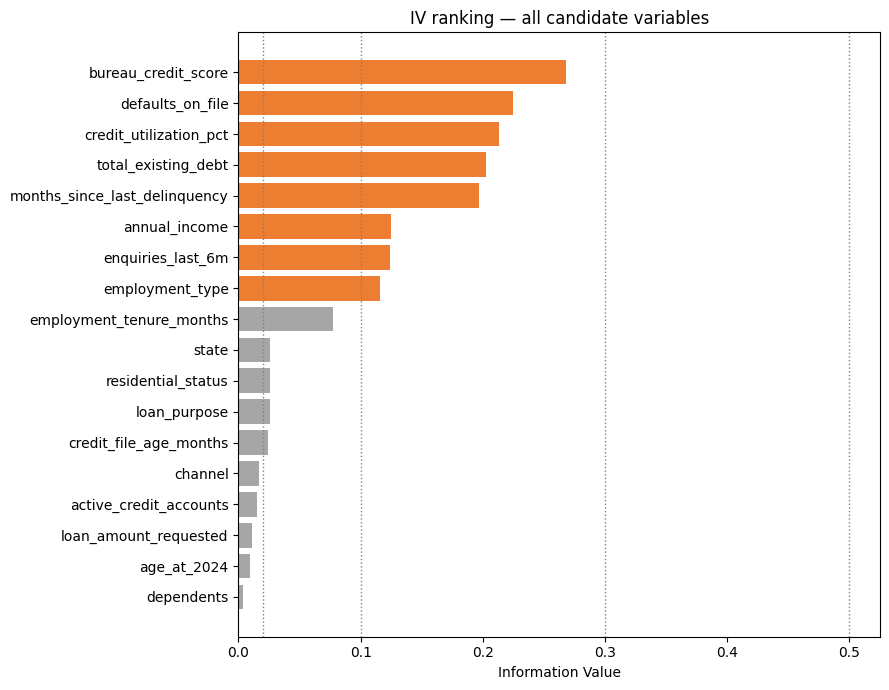

In [6]:
plt.figure(figsize=(9, 7))
colors = ['#C00000' if b in ('Strong','SUSPICIOUSLY STRONG -- investigate') else
          '#ED7D31' if b == 'Medium' else '#A6A6A6' for b in iv_table['Band']]
plt.barh(iv_table.index[::-1], iv_table['IV'][::-1], color=colors[::-1])
plt.axvline(0.02, color='gray', linestyle=':', linewidth=1)
plt.axvline(0.10, color='gray', linestyle=':', linewidth=1)
plt.axvline(0.30, color='gray', linestyle=':', linewidth=1)
plt.axvline(0.50, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Information Value')
plt.title('IV ranking — all candidate variables')
plt.tight_layout()
plt.show()

## 6.5 — Interrogate any "suspiciously strong" result before trusting it

If any variable landed above 0.50, don't celebrate — investigate. Ask:
1. Does this variable have any plausible mechanism to be a DIRECT
   consequence of the target rather than a predictor of it? (Leakage.)
2. Is the strong IV concentrated in one or two bins with very few
   observations, i.e. is it a binning artifact rather than genuine signal?
3. Would this variable have been KNOWN at application time, or could it
   have been influenced by knowledge of the eventual outcome?

For this project: `defaults_on_file` and `bureau_credit_score` are expected
to rank highly (they're genuinely strong, legitimate risk drivers — this was
deliberately built into how the synthetic data was generated, and it mirrors
real bureau-based scorecards where bureau attributes are consistently the
strongest predictors). If either lands in "suspiciously strong" territory,
that's plausible here given how directly we built the synthetic risk
relationship — but it's exactly the kind of result a real analyst would
sanity-check against business intuition and re-verify isn't an artifact of
the (in-sample) binning before trusting it into a model.

In [7]:
suspicious = iv_table[iv_table['Band'] == 'SUSPICIOUSLY STRONG -- investigate']
if len(suspicious) > 0:
    print("Variables flagged for review:")
    print(suspicious)
else:
    print("No variables in the 'suspiciously strong' band.")

No variables in the 'suspiciously strong' band.


## 6.6 — Variable shortlist decision for Stage 7

Combining IV ranking with the binning-quality observations from Stage 5:

**Include (Medium IV or higher, clean/monotonic bins):**
- Variables with IV ≥ 0.10 AND a defensible monotonic WOE trend from Stage 5

**Exclude, with reasons documented (this is the discipline IV alone won't
enforce for you):**
- `gender` — excluded on fair-lending grounds regardless of IV
- `interest_rate_offered` — excluded in Stage 4 on data leakage grounds,
  never even computed here
- Any variable with IV < 0.02 (not useful) — weak signal, adds model
  complexity without benefit, and risks overfitting to noise in a modest
  sample
- Variables flagged as genuinely choppy/non-monotonic in Stage 5
  (`credit_file_age_months`, `loan_amount_requested`) get extra scrutiny
  here — if their IV also comes back weak, that CONFIRMS they're not
  scorecard-ready, consistent with what the binning already suggested

We finalize this list explicitly below and save it, so Stage 7 uses a
documented, reproducible variable set rather than an implicit one.

In [8]:
shortlist = iv_table[(iv_table['IV'] >= 0.10)].index.tolist()
print("Variables with IV >= 0.10 (Medium or higher):")
for v in shortlist:
    print(f"  {v:35s} IV={iv_table.loc[v,'IV']:.4f}  ({iv_table.loc[v,'Band']})")

print("\nExcluded despite being in the candidate list:")
excluded = iv_table[iv_table['IV'] < 0.10].index.tolist()
for v in excluded:
    print(f"  {v:35s} IV={iv_table.loc[v,'IV']:.4f}  ({iv_table.loc[v,'Band']}) -- weak signal")

with open('../01_data/stage7_shortlist.json', 'w') as f:
    json.dump(shortlist, f, indent=2)

# Also persist the full IV lookup (not just the shortlist) so Stage 7 can
# compare IVs when deciding which of two correlated variables to drop.
with open('../01_data/stage7_iv_lookup.json', 'w') as f:
    json.dump(iv_table['IV'].to_dict(), f, indent=2)

print("\nShortlist and full IV lookup saved for Stage 7.")

Variables with IV >= 0.10 (Medium or higher):
  bureau_credit_score                 IV=0.2680  (Medium)
  defaults_on_file                    IV=0.2246  (Medium)
  credit_utilization_pct              IV=0.2132  (Medium)
  total_existing_debt                 IV=0.2029  (Medium)
  months_since_last_delinquency       IV=0.1964  (Medium)
  annual_income                       IV=0.1252  (Medium)
  enquiries_last_6m                   IV=0.1238  (Medium)
  employment_type                     IV=0.1162  (Medium)

Excluded despite being in the candidate list:
  employment_tenure_months            IV=0.0774  (Weak) -- weak signal
  state                               IV=0.0256  (Weak) -- weak signal
  residential_status                  IV=0.0256  (Weak) -- weak signal
  loan_purpose                        IV=0.0255  (Weak) -- weak signal
  credit_file_age_months              IV=0.0240  (Weak) -- weak signal
  channel                             IV=0.0167  (Not useful) -- weak signal
  active_cr

## 6.7 — Checkpoint questions

1. Two variables flagged as correlated in Stage 4.9 were
   `total_existing_debt` and `credit_utilization_pct`. If BOTH make this
   shortlist (check the output above), what problem might that create in
   Stage 7's logistic regression, and how would you plan to handle it — drop
   one now, or wait and check coefficient stability/VIF after fitting the
   model?

2. `bureau_credit_score` alone is likely to dominate this shortlist's IV
   ranking. In a real bank, is it acceptable to build a scorecard that's
   effectively "mostly just the bureau score, plus a few small adjustments"?
   What's the argument FOR including bureau-derived variables prominently,
   and what's the argument for wanting a more balanced set of drivers (hint:
   think about what happens if the bureau's own methodology changes, or if
   MTB wants to differentiate its underwriting from what any lender using
   the same bureau file would already see)?

3. IV was computed here on the FULL modeling dataset — the same data used to
   fit Stage 5's bin boundaries. We flagged this as an optimism risk in the
   introduction. What would you expect to happen to these IV values if
   recomputed on a genuinely held-out test set? Would you expect them to go
   up, down, or stay about the same, and why?